# JP Morgan Chase — AI Finance Agent
## Lab 03 : Machine Learning — Fraud Detection Model
**Author :** Fabrice William FOMHOM  
**Date :** March 2026  
**Objective :** Build a machine learning model to automatically 
detect fraudulent transactions

## What We Build
1. Prepare features for the ML model
2. Train a Random Forest classifier
3. Evaluate model performance
4. Identify the most important fraud signals

In [1]:
# ============================================================
# JP Morgan Chase — Lab 03 : Fraud Detection ML Model
# Step 1 : Import libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             roc_auc_score)
from sklearn.preprocessing import LabelEncoder

# Project paths
BASE_DIR   = r"C:\Users\HP\jpmorgan_finance_agent"
DATA_DIR   = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

# Load dataset
df = pd.read_csv(os.path.join(DATA_DIR, "jpmorgan_transactions.csv"),
                 parse_dates=["date"])

print(f"✅ Dataset loaded  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Fraud cases     : {df['is_fraud'].sum()} ({df['is_fraud'].mean()*100:.2f}%)")
print(f"   Normal cases    : {(df['is_fraud']==0).sum()}")

✅ Dataset loaded  : 1000 rows × 11 columns
   Fraud cases     : 29 (2.90%)
   Normal cases    : 971


In [2]:
# ============================================================
# Step 2 : Feature Engineering
# Convert data into numbers for the ML model
# ============================================================

# Make a copy to avoid modifying original data
df_ml = df.copy()

# Encode categorical columns (text → numbers)
le = LabelEncoder()

df_ml["category_encoded"]   = le.fit_transform(df_ml["category"])
df_ml["merchant_encoded"]   = le.fit_transform(df_ml["merchant"])
df_ml["day_of_week_encoded"]= le.fit_transform(df_ml["day_of_week"])

# Select features for the model
FEATURES = [
    "amount",             # transaction amount
    "month",              # month of year
    "quarter",            # quarter
    "category_encoded",   # type of purchase
    "merchant_encoded",   # where purchased
    "day_of_week_encoded" # day of week
]

TARGET = "is_fraud"

# Create X (features) and y (target)
X = df_ml[FEATURES]
y = df_ml[TARGET]

print("=" * 50)
print("FEATURES PREPARED FOR ML MODEL")
print("=" * 50)
print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"\nFeature columns :")
for f in FEATURES:
    print(f"   → {f}")
print(f"\nClass distribution :")
print(f"   Normal (0) : {(y==0).sum()} transactions")
print(f"   Fraud  (1) : {(y==1).sum()} transactions")

FEATURES PREPARED FOR ML MODEL
Features (X) shape : (1000, 6)
Target   (y) shape : (1000,)

Feature columns :
   → amount
   → month
   → quarter
   → category_encoded
   → merchant_encoded
   → day_of_week_encoded

Class distribution :
   Normal (0) : 971 transactions
   Fraud  (1) : 29 transactions


In [3]:
# ============================================================
# Step 3 : Train/Test Split and Model Training
# ============================================================

# Split data : 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size    = 0.20,      # 20% for testing
    random_state = 42,        # reproducibility
    stratify     = y          # keep fraud ratio balanced
)

print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)
print(f"Training set   : {X_train.shape[0]} transactions")
print(f"Testing set    : {X_test.shape[0]} transactions")
print(f"Fraud in train : {y_train.sum()} cases")
print(f"Fraud in test  : {y_test.sum()} cases")

# ── Train Random Forest Model ────────────────────────────────
print("\n⏳ Training Random Forest model...")

model = RandomForestClassifier(
    n_estimators = 100,    # 100 decision trees
    max_depth    = 10,     # max depth per tree
    random_state = 42,     # reproducibility
    class_weight = "balanced"  # handle fraud imbalance
)

model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print(f"   Trees in forest : {model.n_estimators}")
print(f"   Features used   : {model.n_features_in_}")

TRAIN / TEST SPLIT
Training set   : 800 transactions
Testing set    : 200 transactions
Fraud in train : 23 cases
Fraud in test  : 6 cases

⏳ Training Random Forest model...
✅ Model trained successfully!
   Trees in forest : 100
   Features used   : 6


JP MORGAN — FRAUD MODEL PERFORMANCE REPORT

ROC-AUC Score : 0.7762
(1.0 = perfect, 0.5 = random guessing)

              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98       194
       Fraud       0.00      0.00      0.00         6

    accuracy                           0.97       200
   macro avg       0.48      0.50      0.49       200
weighted avg       0.94      0.97      0.96       200

CONFUSION MATRIX
True  Negatives  (Correct Normal) : 194
False Positives  (False Alarm)    : 0
False Negatives  (Missed Fraud)   : 6
True  Positives  (Caught Fraud)   : 0


c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


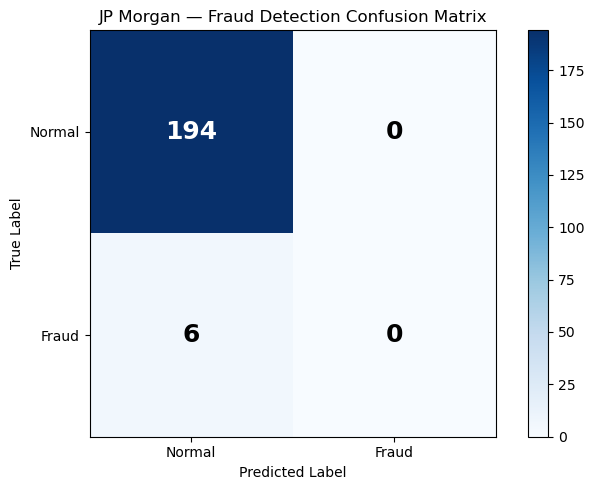


✅ Chart saved : C:\Users\HP\jpmorgan_finance_agent\outputs\04_confusion_matrix.png


In [4]:
# ============================================================
# Step 4 : Model Evaluation
# How well does our model detect fraud?
# ============================================================

# Make predictions on test set
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# ROC-AUC Score (industry standard metric)
auc_score = roc_auc_score(y_test, y_pred_prob)

print("=" * 55)
print("JP MORGAN — FRAUD MODEL PERFORMANCE REPORT")
print("=" * 55)
print(f"\nROC-AUC Score : {auc_score:.4f}")
print("(1.0 = perfect, 0.5 = random guessing)\n")

print(classification_report(y_test, y_pred,
      target_names=["Normal", "Fraud"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("=" * 55)
print("CONFUSION MATRIX")
print("=" * 55)
print(f"True  Negatives  (Correct Normal) : {cm[0][0]}")
print(f"False Positives  (False Alarm)    : {cm[0][1]}")
print(f"False Negatives  (Missed Fraud)   : {cm[1][0]}")
print(f"True  Positives  (Caught Fraud)   : {cm[1][1]}")

# ── Plot Confusion Matrix ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Normal", "Fraud"])
ax.set_yticklabels(["Normal", "Fraud"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i][j]),
                ha="center", va="center",
                fontsize=18, fontweight="bold",
                color="white" if cm[i][j] > cm.max()/2 else "black")

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("JP Morgan — Fraud Detection Confusion Matrix")

plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, "04_confusion_matrix.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Chart saved : {chart_path}")

In [5]:
# ============================================================
# Step 5 : Fix Class Imbalance with SMOTE
# SMOTE = Synthetic Minority Oversampling Technique
# ============================================================

from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("=" * 50)
print("BEFORE vs AFTER SMOTE")
print("=" * 50)
print(f"Before — Normal: {(y_train==0).sum()}, Fraud: {(y_train==1).sum()}")
print(f"After  — Normal: {(y_train_balanced==0).sum()}, Fraud: {(y_train_balanced==1).sum()}")

# Retrain model on balanced data
model_balanced = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 10,
    random_state = 42
)
model_balanced.fit(X_train_balanced, y_train_balanced)

# Evaluate again
y_pred2      = model_balanced.predict(X_test)
y_pred_prob2 = model_balanced.predict_proba(X_test)[:, 1]
auc_score2   = roc_auc_score(y_test, y_pred_prob2)

print(f"\n✅ New ROC-AUC Score : {auc_score2:.4f}")
print(f"\n{classification_report(y_test, y_pred2, target_names=['Normal','Fraud'])}")

BEFORE vs AFTER SMOTE
Before — Normal: 777, Fraud: 23
After  — Normal: 777, Fraud: 777

✅ New ROC-AUC Score : 0.9399

              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99       194
       Fraud       0.62      0.83      0.71         6

    accuracy                           0.98       200
   macro avg       0.81      0.91      0.85       200
weighted avg       0.98      0.98      0.98       200



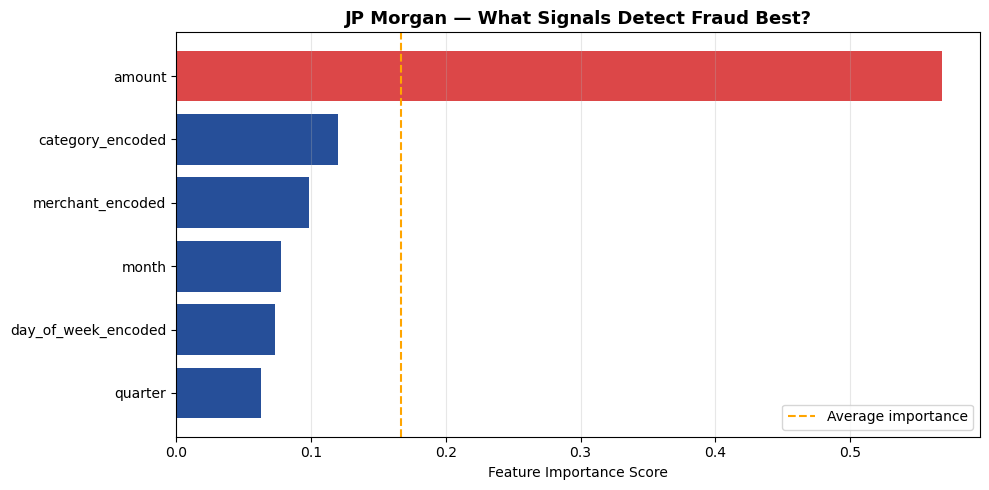

✅ Chart saved!

Feature Importance Ranking :
amount                    ████████████████████████████ 0.5678
category_encoded          █████ 0.1197
merchant_encoded          ████ 0.0982
month                     ███ 0.0779
day_of_week_encoded       ███ 0.0730
quarter                   ███ 0.0633


In [6]:
# ============================================================
# Step 6 : Feature Importance
# Which signals matter most for detecting fraud?
# ============================================================

importance_df = pd.DataFrame({
    "feature"   : FEATURES,
    "importance": model_balanced.feature_importances_
}).sort_values("importance", ascending=True)

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#D62728" if imp > 0.25 else "#003087" 
          for imp in importance_df["importance"]]

ax.barh(importance_df["feature"], 
        importance_df["importance"],
        color=colors, alpha=0.85)

ax.set_title("JP Morgan — What Signals Detect Fraud Best?",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Feature Importance Score")
ax.axvline(x=importance_df["importance"].mean(), 
           color="orange", linestyle="--", 
           label=f"Average importance")
ax.legend()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, "05_feature_importance.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print("✅ Chart saved!")
print(f"\nFeature Importance Ranking :")
print("=" * 45)
for _, row in importance_df.sort_values(
        "importance", ascending=False).iterrows():
    bar = "█" * int(row["importance"] * 50)
    print(f"{row['feature']:<25} {bar} {row['importance']:.4f}")